In [21]:
import torch
import sys
import os
sys.path.append("../models")

In [22]:
import learnable_vector

In [23]:
model_config = {
    "input_size": [408, 29, 55],
    "latent_size": 8
}

In [24]:
model = learnable_vector.LearnableLocationResMLP(
        config=model_config,
        #input_size=len(training_set.input_indices),
        input_size=model_config["input_size"][0],
        output_size=30,
        m=512,
        activation='relu',
        num_blocks=7,
        sub_region_mask=None
    )

Learnable vector, resmlp: True, latent_dim 8


In [25]:
resume = torch.load("../offline_test/checkpoint.pth.tar", map_location=torch.device('cpu'))

In [26]:
model.load_state_dict(resume["state_dict"])

<All keys matched successfully>

In [27]:
loc_code = model.learnable_location

In [28]:
loc_code.shape

torch.Size([1, 8, 29, 55])

In [29]:
loc_code = loc_code.detach().numpy()

In [30]:
import matplotlib.pyplot as plt

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import COASTLINE
def plot_spatial(lon, lat, data, cbar_label=None, title=None, cmap="bwr",
                  vmin=None, vmax=None, norm=None, extend="both", ax=None):
    # Using PlateCarree projection which is commonly used for lat/lon data.
    if ax is None:
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))  
    if vmin is not None:
        img = ax.contourf(lon, lat, data, np.linspace(vmin, vmax, 20), cmap=cmap, 
                      transform=ccrs.PlateCarree(), norm=norm, extend=extend)
    else:
        img = ax.contourf(lon, lat, data, 20, cmap=cmap, 
                        transform=ccrs.PlateCarree(), norm=norm, extend=extend)
    # plt.imshow(r2, cmap="bwr", vmin=0, vmax=1)
    # Draw and label gridlines
    # Add coastlines
    ax.add_feature(COASTLINE, linewidth=0.5, edgecolor='black')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False  # Don't display top x-axis labels
    gl.right_labels = False  # Don't display right y-axis labels
    cbar = plt.colorbar(img,shrink=0.3)
    if cbar_label is not None:
        cbar.set_label(cbar_label)
    if title is not None:
        plt.title(title)
def get_min_max_coords(mask, pad):
    min_x = np.min(np.where(mask)[0])
    max_x = np.max(np.where(mask)[0])
    min_y = np.min(np.where(mask)[1])
    max_y = np.max(np.where(mask)[1])
    # wid_x = math.ceil((max_x - min_x)/2)*2
    # wid_y = math.floor((max_y - min_y)/2)*2
    # return int(min_x-pad), int(min_x+wid_x+pad), \
    #     int(min_y-pad), int(min_y+wid_y+pad)
    return min_x-pad, max_x+pad, min_y-pad, max_y+pad
region_mask = np.load("../consts/pacific_region_mask.npy")
min_x, max_x, min_y, max_y = get_min_max_coords(region_mask, 2)
lon = np.linspace(0,357.5,144)
lat = np.linspace(-90,90,96)
print("Region window coordinates: ", lon[min_y], lon[max_y], lat[min_x], lat[max_x])
def plot_pacific(data, **kwargs):
#     full_data = np.zeros((96,144))
#     for i in range(96):
#         for j in range(144):
#             full_data[i,j] = None
#     full_data[min_x:max_x,min_y:max_y] = data
    plot_spatial(lon[min_y:max_y], lat[min_x:max_x], data, **kwargs)

Region window coordinates:  110.0 247.5 -27.473684210526322 27.473684210526315


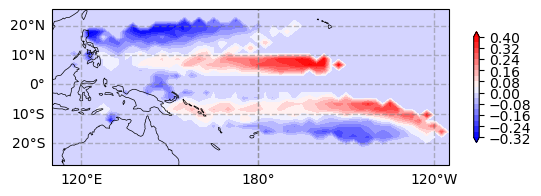

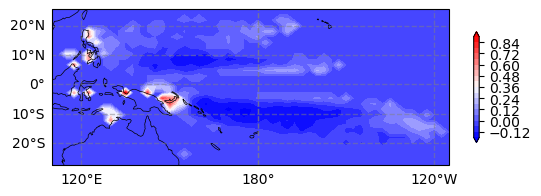

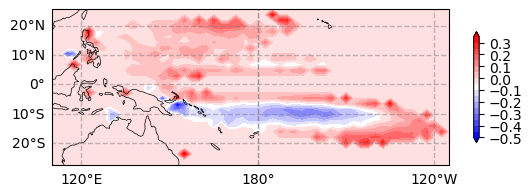

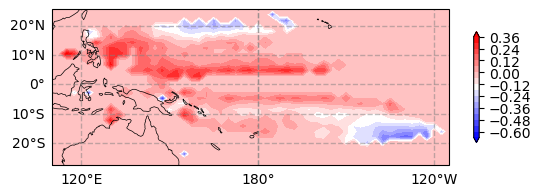

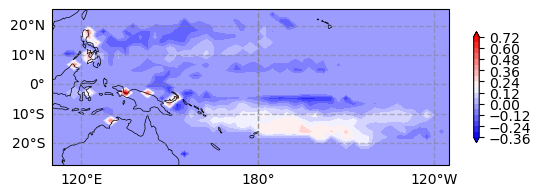

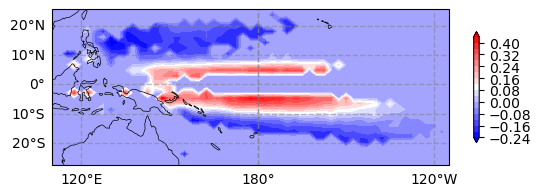

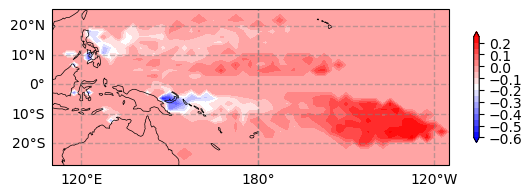

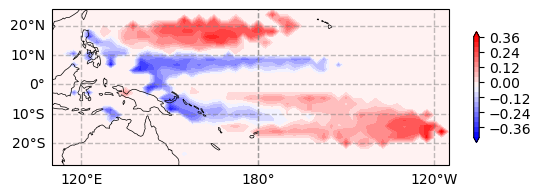

In [33]:
for i in range(8):
    plot_pacific(loc_code[0,i])
    plt.show()